# Global Economic Development & Inequality Analysis
This project is an implementation of a data visualization case study proposed by Maven Analytics. It explores global economic trends using  macro-economic indicators from the World Bank and Human Development Index (HDI) data from the United Nations.

**Project Description**
* **Data Wrangling**: Datasets integration and `pivot_table` for effective data reshaping.
* **Visualization**: Designed a unified visual dashboard using `matplotlib.gridspec`. Refined ggplot styles, refining axes, and adjusting spine parameters to create a professional report.
* **Customization**: Beyond the guided workflow, I modified style parameters to ensure visual consistency and clarity across multiple chart types.



## Data preparation

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [23]:
wbank = pd.read_excel("Data/WorldBank.xlsx")
wbank["Population (M)"] = (wbank["GDP (USD)"] / wbank["GDP per capita (USD)"])/1_000_000
hdi = pd.read_csv("Data/HDI.csv")
wb_hdi_2014 = pd.merge(wbank.query("Year == 2014"), hdi[["iso3", "hdi_2014"]], left_on="Country Code", right_on="iso3", how="left")

In [24]:
gdp_pivot = wbank.pivot_table(index="Year", columns="Region", values="GDP (USD)", aggfunc="sum")
pop_pivot = wbank.pivot_table(index="Year", columns="Region", values="Population (M)", aggfunc="sum")
wb_hdi_by_region = wb_hdi_2014.groupby("Region").agg(avg_hdi = ("hdi_2014", "mean")).sort_values("avg_hdi", ascending=False)

## Visualization

### Set style


In [25]:
plt.style.use("ggplot")
plt.rc("axes", facecolor="white", grid=True, edgecolor="black", linewidth=0.4)
plt.rc("axes.spines", left=True, bottom=True)
plt.rc("grid", color="#edede9")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc("axes.spines", left=True, right=False, top=False, bottom=True )

### Final Report

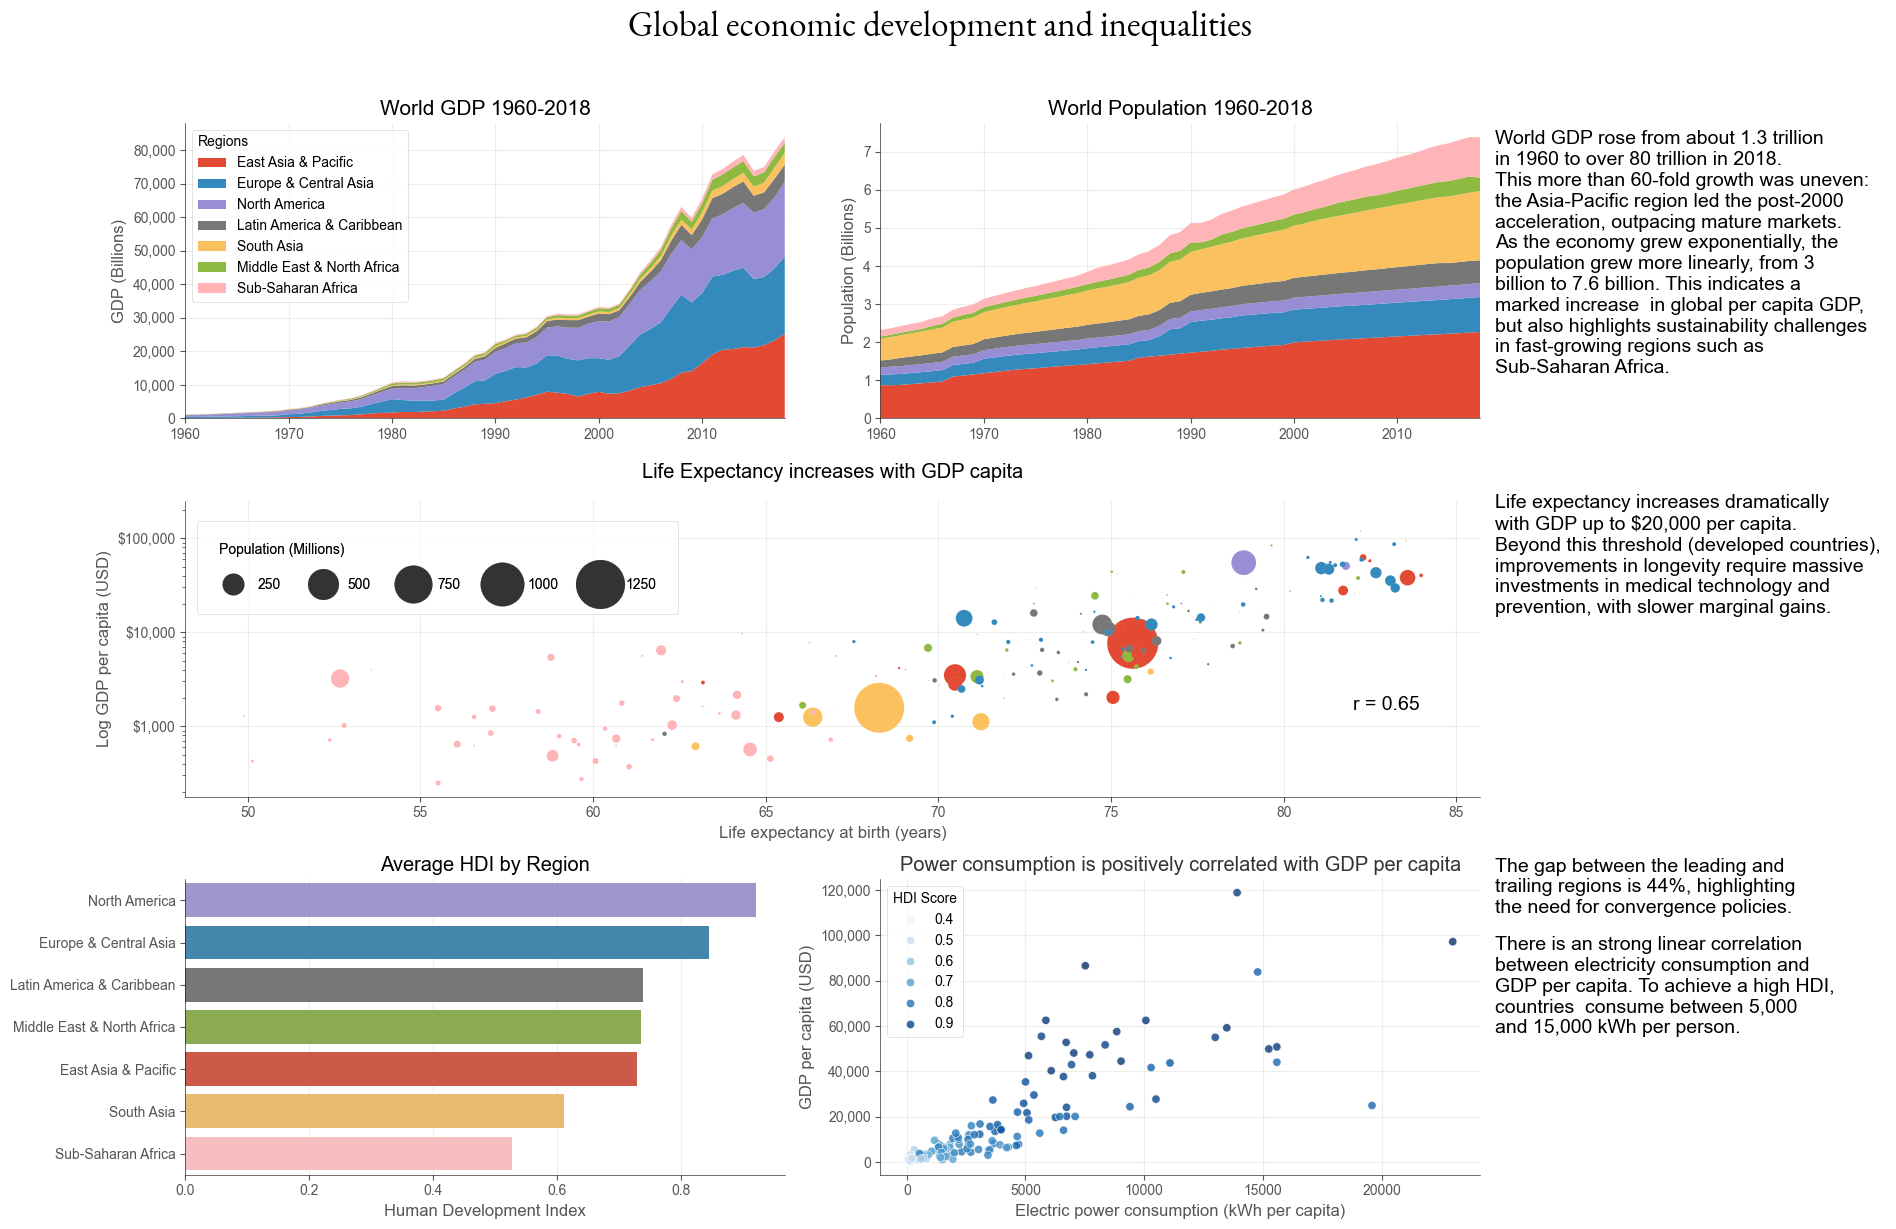

In [26]:
# CREATING THE LAYOUT
fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(nrows=3, ncols=2)


ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])
ax4 = fig.add_subplot(gs[2,0])
ax5 = fig.add_subplot(gs[2,1])

#--------------------------------------------------------------------------------------------------------------------------------

### POPULATION AND GDP OVER TIME
# Gdp
countries_desc_gdp = gdp_pivot.iloc[-1].sort_values(ascending=False).index 
# list of countries ordered from the highest GDP in 2018 to the lowest. This puts lowest GDP countries at the top of the stackplot.
gdp_pivot = gdp_pivot.reindex(labels=countries_desc_gdp, axis=1)

ax1.stackplot(gdp_pivot.index,
             [gdp_pivot[region]/1_000_000_000 for region in countries_desc_gdp]) # by pivoting the data before, each column represents a distinct country.
ax1.yaxis.set_major_formatter("{x:,.0f}")
ax1.set_xlim(1960,2018)

ax1.set_title("World GDP 1960-2018", fontsize=15)
ax1.set_ylabel("GDP (Billions)")
ax1.legend(countries_desc_gdp, loc="upper left", title="Regions", alignment="left")


# Population
ax2.stackplot(pop_pivot.index,
             [pop_pivot[region]/1000 for region in countries_desc_gdp]) # I used the gdp ordered list to mantain the color code consistent across all the charts.
ax2.yaxis.set_major_formatter("{x:,.0f}")
ax2.set_xlim(1960,2018)
ax2.set_title("World Population 1960-2018", fontsize=15)
ax2.set_ylabel("Population (Billions)")

#--------------------------------------------------------------------------------------------------------------------------------

# LIFE EXPECTANCY
min_pop = wb_hdi_2014["Population (M)"].min()
max_pop = wb_hdi_2014["Population (M)"].max()

sns.scatterplot(data=wb_hdi_2014, 
                x="Life expectancy at birth (years)", 
                y= "GDP per capita (USD)", 
                size="Population (M)", hue="Region", sizes=(min_pop, max_pop),
                hue_order=countries_desc_gdp,ax=ax3)


ax3.set_ylabel("Log GDP per capita (USD)")
ax3.set_yscale("log")

# Custom legend
ax3.legend().remove() # remove original seaborn legend
handles, labels = ax3.get_legend_handles_labels()
pop_legend = fig.legend(handles[-5:], labels[-5:], 
                        bbox_to_anchor =(0.46,0.6), ncols=5, borderpad=1.6, 
                        framealpha=0.5, title="Population (Millions)", alignment="left", labelspacing=1.5)
ax3.add_artist(pop_legend)

ax3.set_title("Life Expectancy increases with GDP capita", y=1.05)
ax3.yaxis.set_major_formatter("${x:,.0f}") # remove scientific notation

#--------------------------------------------------------------------------------------------------------------------------------
# HDI BY REGION
sns.barplot(data=wb_hdi_by_region, y="Region", x="avg_hdi", hue="Region", errorbar=None, hue_order=countries_desc_gdp, ax=ax4)
ax4.set_title("Average HDI by Region")
ax4.set_ylabel(None)
ax4.set_xlabel("Human Development Index")


#--------------------------------------------------------------------------------------------------------------------------------
# POWER CONSUMPTION

sns.scatterplot(data=wb_hdi_2014[wb_hdi_2014["Country Name"]!="Iceland"], 
                x="Electric power consumption (kWh per capita)",
                y="GDP per capita (USD)",
                hue="hdi_2014",
                palette="Blues",
                alpha=0.8,
                ax=ax5)
ax5.legend(title="HDI Score")
ax5.yaxis.set_major_formatter("{x:,.0f}")
ax5.set_title("Power consumption is positively correlated with GDP per capita", alpha=0.8)



#--------------------------------------------------------------------------------------------------------------------------------
text1='''
World GDP rose from about 1.3 trillion 
in 1960 to over 80 trillion in 2018. 
This more than 60-fold growth was uneven: 
the Asia-Pacific region led the post-2000 
acceleration, outpacing mature markets.
As the economy grew exponentially, the 
population grew more linearly, from 3 
billion to 7.6 billion. This indicates a 
marked increase  in global per capita GDP, 
but also highlights sustainability challenges 
in fast-growing regions such as 
Sub-Saharan Africa.
'''
text2 = '''
Life expectancy increases dramatically 
with GDP up to $20,000 per capita. 
Beyond this threshold (developed countries), 
improvements in longevity require massive 
investments in medical technology and 
prevention, with slower marginal gains.
'''
text3=''' 
The gap between the leading and 
trailing regions is 44%, highlighting 
the need for convergence policies.
'''
text4 = ''' 
There is an strong linear correlation 
between electricity consumption and 
GDP per capita. To achieve a high HDI, 
countries  consume between 5,000 
and 15,000 kWh per person.
'''

corr = corr = wb_hdi_2014[["GDP per capita (USD)", "hdi_2014"]].corr().iloc[0,1].round(2)

fig.text(1, 0.7, s=text1, fontsize=14)
fig.text(1, 0.5, s=text2, fontsize=14)
fig.text(1, 0.25, s=text3, fontsize=14)
fig.text(1, 0.15, s=text4, fontsize=14)
fig.suptitle("Global economic development and inequalities", fontsize=25, x=0.63, y=1.02, fontname="EB Garamond")
ax3.annotate(xy=(82,1500), text=f"r = {corr}", fontsize=14)

plt.tight_layout()
plt.savefig("report.png", bbox_inches="tight", dpi=300)
plt.show()